In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from time import time
from numpy.typing import NDArray
from algorithms.matrix_free_rsvd import MatrixFreeRSVD
from fenics import (
    FunctionSpace, DirichletBC, Constant, TrialFunction, TestFunction,
    dot, grad, dx, assemble, UnitSquareMesh
)

# LaTeX formatted figures
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

M = ['o', '*', '^', 's']
MS = [6, 8, 6, 6]

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
class AssembleForwardOperator:
    """
    Assemble the forward operator K and record the computational time.
    """
    def __init__(self, V_h: FunctionSpace):
        self.V_h = V_h
        self.bdofs = self._get_boundary_dofs()
        self.N = V_h.dim()
        self.N_b = len(self.bdofs)
        self.dt = None
    
    def assemble_K(self) -> NDArray:
        """Get the exact discrete forward operator K"""
        t0 = time()
        S = self.assemble_S()
        T = self.assemble_T()
        self.dt = time() - t0 
        return T @ S
    
    def assemble_S(self, sigma: float=1.0, k: float=1.0) -> NDArray:
        """Get the exact discrete PDE operator S."""
        u = TrialFunction(self.V_h)
        v = TestFunction(self.V_h)

        sigma = Constant(sigma)
        k = Constant(k)
        a = sigma * dot(grad(u), grad(v)) * dx + k * u * v * dx  # LHS
        m = u * v * dx  # RHS

        # Assemble A, M and S
        A = assemble(a).array()
        M = assemble(m).array()
        S = np.linalg.solve(A, M)  # S = A^{-1} @ M
        return S
    
    def assemble_T(self) -> NDArray:
        """Get the exact discrete trace operator T."""
        T = np.zeros((self.N_b, self.N))
        for i, j in enumerate(self.bdofs):
            T[i, j] = 1.0
        return T
    
    def _get_boundary_dofs(self) -> NDArray:
        def boundary(x, on_boundary):
            return on_boundary

        bc = DirichletBC(self.V_h, Constant(0.0), boundary)
        bc_dict = bc.get_boundary_values()
        return np.array(sorted(bc_dict.keys()), dtype=int)
    

def setup_function_space(n):
    mesh = UnitSquareMesh(n, n)
    V_h = FunctionSpace(mesh, 'CG', 1)
    return V_h


In [60]:
def run_experiment(n_range, k_range):
    """
    Run a single experiment: time the assembly of K and the rSVD approximation
    over a range of mesh shapes (n_range) and a range of target ranks (k_range).
    """
    nn, nk = len(n_range), len(k_range)
    results = {
        'exact': np.zeros(nn),
        'rsvd': np.zeros((nn, nk)),
        'N': [],
        'N_b': []
    }

    for i, n in enumerate(n_range):
        V_h = setup_function_space(n)
        exact = AssembleForwardOperator(V_h=V_h)

        # Time to assemble the exact K
        exact.assemble_K()
        dt_exact = exact.dt

        # Time to approximate K
        rsvd = MatrixFreeRSVD(V_h)
        dt_rsvd = np.zeros(len(k_range))
        for j, k in enumerate(k_range):
            t0 = time()
            U, S, VT = rsvd.mf_rsvd(k=k)
            K = U @ np.diag(S) @ VT
            dt_rsvd[j] = time() - t0

        results['exact'][i] = dt_exact
        results['rsvd'][i, :] = dt_rsvd
        results['N'].append(rsvd.N)
        results['N_b'].append(rsvd.N_b)

    return results


def run_r_experiments(n_range, k_range, r):
    nn, nk = len(n_range), len(k_range)
    results = {
        'exact': np.zeros((r, nn)),  # (repeats, n_range)
        'rsvd': np.zeros((r, nn, nk)),  # (repeats, n_range, k_range)
        'N': [],
        'N_b': []
    }

    for ri in range(r):
        results_i = run_experiment(n_range, k_range)
        results['exact'][ri, :] = results_i['exact']
        results['rsvd'][ri, :, :] = results_i['rsvd']

    results['N'] = results_i['N']
    results['N_b'] = results_i['N_b']

    return results


k_range = np.array([5, 10, 20])
n_range = np.arange(8, 64, 4)
results = run_r_experiments(n_range, k_range, r=1)

In [61]:
medians = {
    key: np.median(val, axis=0) for key, val in results.items()
}
medians['rsvd'].shape, medians['exact'].shape

((14, 3), (14,))

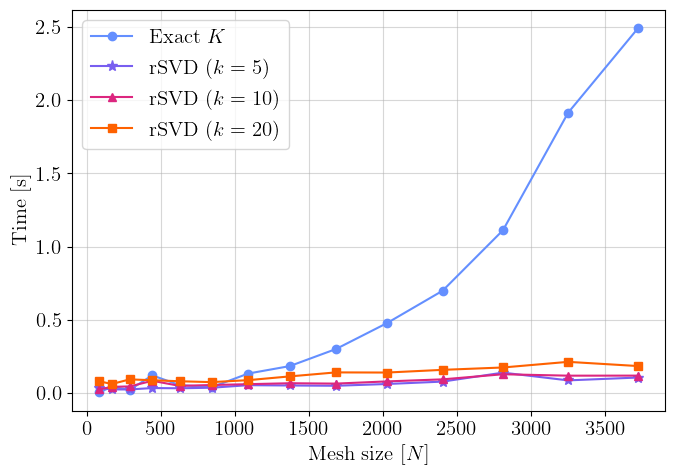

In [79]:
from utils.colors import C5

fig, axes = plt.subplots(1, 1, figsize=(7, 5))
ax1 = axes

x_axis = results['N']
ax1.plot(x_axis, medians['exact'],      c=C5[0], marker=M[0], ms=MS[0], label='Exact $K$')
ax1.plot(x_axis, medians['rsvd'][:, 0], c=C5[1], marker=M[1], ms=MS[1], label='rSVD ($k=5$)')
ax1.plot(x_axis, medians['rsvd'][:, 1], c=C5[2], marker=M[2], ms=MS[2], label='rSVD ($k=10$)')
ax1.plot(x_axis, medians['rsvd'][:, 2], c=C5[3], marker=M[3], ms=MS[3], label='rSVD ($k=20$)')

ax1.set_xlabel("Mesh size [$N$]")
ax1.set_ylabel("Time [s]")
#ax1.axhline(0, c='black', ls='--', alpha=.5)
ax1.legend()
ax1.grid(True, alpha=.5)

plt.tight_layout()
plt.plot()

figname = 'exact_vs_rsvd_comp_time.png'
plt.savefig(f'../figures/{figname}', dpi=300, bbox_inches='tight')